In [22]:
import av
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

np.random.seed(42)
torch.manual_seed(42)

def read_video_pyav(container, indices):
    frames = []
    container.seek(0)
    start_index = indices[0]
    end_index = indices[-1]
    for i, frame in enumerate(container.decode(video=0)):
        if i > end_index:
            break
        if i >= start_index and i in indices:
            frames.append(frame)
    return np.stack([x.to_ndarray(format="rgb24") for x in frames])

In [23]:
filepath = '../../data/sintel_trailer-1080p.mp4'

container = av.open(filepath)

In [24]:
# Improved Convolutional Autoencoder with residual connections
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(channels)
        
    def forward(self, x):
        residual = x
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += residual
        return F.relu(out)

class Encoder(nn.Module):
    def __init__(self, latent_channels=64):
        super().__init__()
        # Progressive downsampling: 224 -> 112 -> 56 -> 28 -> 14 -> 7
        self.conv1 = nn.Conv2d(3, 64, 4, stride=2, padding=1)  # 112x112
        self.bn1 = nn.BatchNorm2d(64)
        self.res1 = ResidualBlock(64)
        
        self.conv2 = nn.Conv2d(64, 128, 4, stride=2, padding=1)  # 56x56
        self.bn2 = nn.BatchNorm2d(128)
        self.res2 = ResidualBlock(128)
        
        self.conv3 = nn.Conv2d(128, 256, 4, stride=2, padding=1)  # 28x28
        self.bn3 = nn.BatchNorm2d(256)
        self.res3 = ResidualBlock(256)
        
        self.conv4 = nn.Conv2d(256, 512, 4, stride=2, padding=1)  # 14x14
        self.bn4 = nn.BatchNorm2d(512)
        
        self.conv5 = nn.Conv2d(512, latent_channels, 4, stride=2, padding=1)  # 7x7
        self.bn5 = nn.BatchNorm2d(latent_channels)
        
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.res1(x)
        
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.res2(x)
        
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.res3(x)
        
        x = F.relu(self.bn4(self.conv4(x)))
        x = F.relu(self.bn5(self.conv5(x)))
        
        return x

class Decoder(nn.Module):
    def __init__(self, latent_channels=64):
        super().__init__()
        self.conv1 = nn.ConvTranspose2d(latent_channels, 512, 4, stride=2, padding=1)  # 14x14
        self.bn1 = nn.BatchNorm2d(512)
        
        self.conv2 = nn.ConvTranspose2d(512, 256, 4, stride=2, padding=1)  # 28x28
        self.bn2 = nn.BatchNorm2d(256)
        self.res2 = ResidualBlock(256)
        
        self.conv3 = nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1)  # 56x56
        self.bn3 = nn.BatchNorm2d(128)
        self.res3 = ResidualBlock(128)
        
        self.conv4 = nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1)  # 112x112
        self.bn4 = nn.BatchNorm2d(64)
        self.res4 = ResidualBlock(64)
        
        self.conv5 = nn.ConvTranspose2d(64, 3, 4, stride=2, padding=1)  # 224x224
        
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.res2(x)
        
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.res3(x)
        
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.res4(x)
        
        x = torch.sigmoid(self.conv5(x))
        
        return x

class VariableRateAutoencoder(nn.Module):
    def __init__(self, latent_channels=64):
        super().__init__()
        self.encoder = Encoder(latent_channels)
        self.decoder = Decoder(latent_channels)
        self.latent_channels = latent_channels
        
    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed, latent
    
    def compress_and_reconstruct(self, x, keep_ratio=1.0):
        """
        Compress by keeping only top-k latent coefficients by magnitude
        """
        with torch.no_grad():
            latent = self.encoder(x)
            
            if keep_ratio < 1.0:
                # Flatten spatial dimensions
                B, C, H, W = latent.shape
                latent_flat = latent.view(B, -1)  # (B, C*H*W)
                
                # Calculate how many coefficients to keep
                total_coeffs = latent_flat.shape[1]
                keep_count = int(total_coeffs * keep_ratio)
                
                # Keep top-k by absolute value (most important)
                abs_values = torch.abs(latent_flat)
                threshold_values, _ = torch.kthvalue(abs_values, total_coeffs - keep_count + 1, dim=1)
                threshold = threshold_values.unsqueeze(1)
                
                # Zero out small coefficients
                mask = abs_values >= threshold
                latent_compressed = latent_flat * mask.float()
                latent_compressed = latent_compressed.view(B, C, H, W)
            else:
                latent_compressed = latent
                keep_count = latent.numel() // latent.shape[0]
            
            # Decode
            reconstructed = self.decoder(latent_compressed)
            
            return reconstructed, latent_compressed, keep_count

In [25]:
# Dataset
class FrameDataset(Dataset):
    def __init__(self, frames, img_size=224):
        self.frames = frames
        self.img_size = img_size
        
    def __len__(self):
        return len(self.frames)
    
    def __getitem__(self, idx):
        frame = self.frames[idx]
        frame = torch.from_numpy(frame).float() / 255.0
        frame = frame.permute(2, 0, 1)
        frame = F.interpolate(frame.unsqueeze(0), size=(self.img_size, self.img_size), 
                             mode='bilinear', align_corners=False).squeeze(0)
        return frame

In [26]:
# Load data
container = av.open(filepath)
total_frames = container.streams.video[0].frames

indices = list(range(0, total_frames))
all_frames = read_video_pyav(container, indices)

# Split
indices_shuffled = np.random.permutation(len(all_frames))
train_size = int(0.15 * len(all_frames))
train_indices = indices_shuffled[:train_size]
test_indices = indices_shuffled[train_size:]

frames_train = all_frames[train_indices]
frames_test = all_frames[test_indices]

dataset = FrameDataset(frames_train)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True, 
                       generator=torch.Generator().manual_seed(42))

In [27]:
# Train a single high-quality autoencoder
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = VariableRateAutoencoder(latent_channels=128)
model.to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

num_epochs = 40

model.train()
for epoch in range(num_epochs):
    total_loss = 0
    for batch in dataloader:
        batch = batch.to(device)
        
        reconstructed, _ = model(batch)
        loss = criterion(reconstructed, batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(dataloader)
    scheduler.step(avg_loss)
    
    if (epoch + 1) % 5 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.6f}, LR: {optimizer.param_groups[0]["lr"]:.6f}')

Epoch [5/40], Loss: 0.014858, LR: 0.001000
Epoch [10/40], Loss: 0.011782, LR: 0.001000
Epoch [15/40], Loss: 0.009629, LR: 0.000500
Epoch [20/40], Loss: 0.009704, LR: 0.000500
Epoch [25/40], Loss: 0.009579, LR: 0.000250
Epoch [30/40], Loss: 0.007883, LR: 0.000250
Epoch [35/40], Loss: 0.007189, LR: 0.000250
Epoch [40/40], Loss: 0.006974, LR: 0.000125


In [28]:
# Evaluate at different compression ratios
keep_ratios = [0.50 * (i + 1) / 16 for i in range(16)]
all_results = []

model.eval()
for keep_ratio in keep_ratios:
    for frame_idx in tqdm(range(len(frames_test)), desc=f"Processing frames"):
        frame = frames_test[frame_idx]
        frame_tensor = torch.from_numpy(frame).float() / 255.0
        frame_tensor = frame_tensor.permute(2, 0, 1).unsqueeze(0)
        frame_tensor = F.interpolate(frame_tensor, size=(224, 224), 
                                    mode='bilinear', align_corners=False)
        frame_tensor = frame_tensor.to(device)
        
        # Compress and reconstruct
        reconstructed, latent_compressed, keep_count = model.compress_and_reconstruct(
            frame_tensor, keep_ratio=keep_ratio
        )
        
        # Calculate size (only non-zero coefficients)
        size_bytes = int(keep_count * 4)  # 4 bytes per float32
        
        # Calculate MSE
        mse = F.mse_loss(reconstructed, frame_tensor).item()*255*255
        
        all_results.append({
            'frame': frame_idx + 1,
            'keep_ratio': keep_ratio,
            'mse': mse,
            'size_bytes': size_bytes
        })

Processing frames:   0%|          | 0/1066 [00:00<?, ?it/s]

Processing frames: 100%|██████████| 1066/1066 [00:04<00:00, 254.25it/s]


In [29]:
# Save results
df = pd.DataFrame(all_results)
df = df.sort_values(['frame', 'keep_ratio'], ascending=[True, False])

output_file = 'varrate_compression_results.csv'
df.to_csv(output_file, index=False)

print(f"\nSummary statistics by keep ratio:")
summary = df.groupby('keep_ratio').agg({
    'mse': ['mean', 'std'],
    'size_bytes': 'first'
}).round(6)
print(summary)


Summary statistics by keep ratio:
                    mse              size_bytes
                   mean          std      first
keep_ratio                                     
0.03125     4673.235905  5495.275270        784
0.06250     3868.963322  4604.805073       1568
0.09375     3271.459613  3895.732952       2352
0.12500     2798.301112  3324.215789       3136
0.15625     2406.456460  2844.424163       3920
0.18750     2074.134499  2430.049174       4704
0.21875     1782.996608  2059.232223       5488
0.25000     1530.243313  1731.243457       6272
0.28125     1309.269422  1441.437970       7056
0.31250     1116.740371  1187.924335       7840
0.34375      955.094103   977.069797       8624
0.37500      823.715765   809.491550       9408
0.40625      715.520194   674.084994      10192
0.43750      627.484718   569.264464      10976
0.46875      555.771842   491.359909      11760
0.50000      500.297426   437.889335      12544


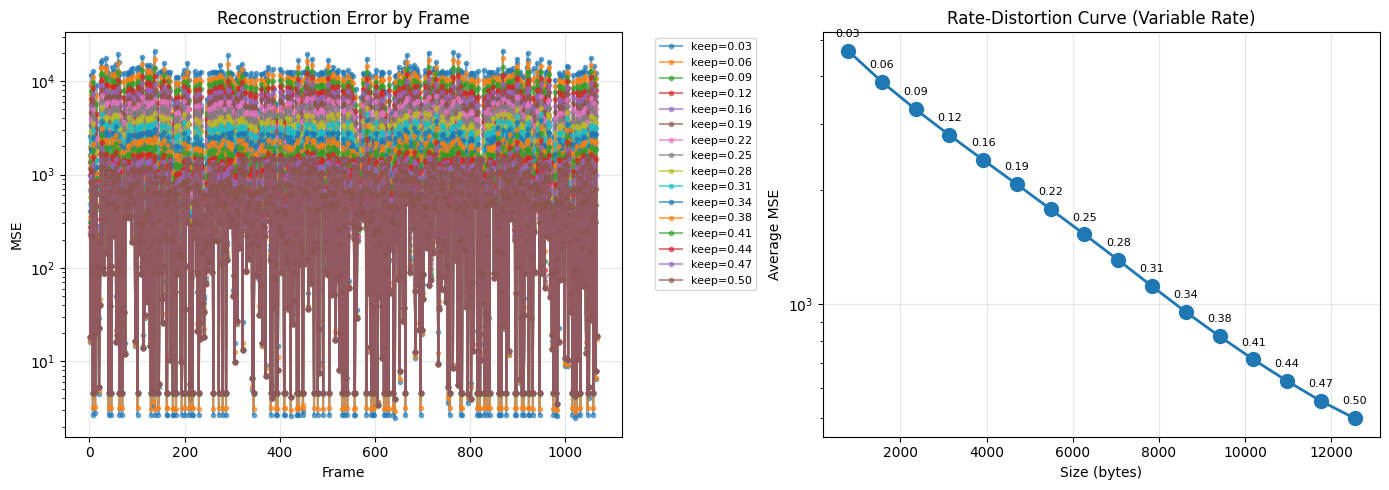

In [30]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: MSE by frame
for keep_ratio in keep_ratios:
    data = df[df['keep_ratio'] == keep_ratio]
    axes[0].plot(data['frame'], data['mse'], 
                label=f'keep={keep_ratio:.2f}', 
                marker='o', alpha=0.6, markersize=3)

axes[0].set_xlabel('Frame')
axes[0].set_ylabel('MSE')
axes[0].set_title('Reconstruction Error by Frame')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# Plot 2: Rate-Distortion curve
avg_mse = df.groupby('keep_ratio')['mse'].mean()
avg_size = df.groupby('keep_ratio')['size_bytes'].first()

# Sort by size for proper curve
sort_idx = avg_size.argsort()
avg_size_sorted = avg_size.iloc[sort_idx]
avg_mse_sorted = avg_mse.iloc[sort_idx]

axes[1].plot(avg_size_sorted, avg_mse_sorted, marker='o', markersize=10, linewidth=2)
for i in range(len(avg_size_sorted)):
    keep_r = avg_size_sorted.index[i]
    axes[1].annotate(f'{keep_r:.2f}', 
                     (avg_size_sorted.iloc[i], avg_mse_sorted.iloc[i]),
                     textcoords="offset points", 
                     xytext=(0,10), 
                     ha='center',
                     fontsize=8)

axes[1].set_xlabel('Size (bytes)')
axes[1].set_ylabel('Average MSE')
axes[1].set_title('Rate-Distortion Curve (Variable Rate)')
axes[1].grid(True, alpha=0.3)
axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig('varrate_compression_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
# Map keep_ratio to "components" (1-16) for simu5g compatibility
keep_ratio_to_level = {ratio: level for level, ratio in enumerate(sorted(keep_ratios), start=1)}

df['components'] = df['keep_ratio'].map(keep_ratio_to_level)

# Match PCA format exactly: frame, components, mse, size_bytes
df = df[['frame', 'components', 'mse', 'size_bytes']]

df.to_csv('varrate_compression_results.csv', index=False)